# 04 — Cross-Market Arbitrage Analysis (Hypothesis H3, proxy version)

> **Goal:** test whether markets sharing a common underlying event
> (same category, same resolution week) exhibit coherent price movements,
> as arbitrage theory would predict.
>
> **Author:** Lucas Marque  
> **Date:** April 19, 2026  
> **Project:** [polymarket-calibration-study](https://github.com/l-marque/calibration-study)

## Hypothesis H3 (preregistered) — proxy version

**Ideal test (not feasible with current data):** for pairs of complementary
markets where $P(A) + P(\bar{A}) = 1$ should hold, test whether observed
prices systematically deviate from 1, creating arbitrage opportunities.

**Proxy test used here:** group markets by shared cluster (same category +
same resolution week). Compute pairwise correlations of drifts
(`price_t24h − price_t48h`) within each cluster. Under efficient markets
with shared information, within-cluster correlations should be significantly
positive.

**H0:** within-cluster drift correlations are distributed around zero
(independent markets).

**H1:** within-cluster drift correlations are significantly positive
(information is shared within clusters, consistent with efficiency).

## Scope and limitations

- Proxy test based on cluster co-movement, not direct arbitrage identification.
- Markets in same cluster may not be complementary — just related by timing
  and category.
- Correlations are sensitive to sample size per cluster; small clusters
  (< 3 markets) are excluded.

In [1]:
import sys
import sqlite3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
DB_PATH = PROJECT_ROOT / "polymarket.db"
assert DB_PATH.exists()

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"Python  : {sys.version.split()[0]}")
print(f"DB      : {DB_PATH}")

Python  : 3.12.10
DB      : c:\Users\lucas\polymarket-calibration-study\polymarket.db


In [2]:
def load_clusters_dataset(db_path: Path, min_duration_days: float = 3.0,
                           min_volume: float = 1000.0) -> pd.DataFrame:
    """
    Load markets with drift data, then assign cluster_id based on
    (category, resolution_week).
    """
    HOLDOUT_DAYS = 30
    OFFSET_48H = 48 * 3600
    OFFSET_24H = 24 * 3600

    conn = sqlite3.connect(db_path)
    markets = pd.read_sql_query(
        """
        SELECT market_id, question, slug, yes_token_id,
               start_ts, end_ts, resolved_outcome,
               volume_total_usd, closed
        FROM markets
        """, conn)
    prices = pd.read_sql_query(
        "SELECT token_id, ts, price FROM price_history", conn)
    conn.close()

    now = pd.Timestamp.utcnow().tz_localize(None).timestamp()
    markets["truly_resolved"] = (
        (markets["closed"] == 1)
        & (markets["end_ts"] <= now)
        & (markets["resolved_outcome"].isin(["YES", "NO"]))
    )
    markets["resolution_age_days"] = (now - markets["end_ts"]) / 86400.0
    markets["truly_holdout"] = (
        markets["truly_resolved"] & (markets["resolution_age_days"] < HOLDOUT_DAYS)
    )
    markets["analysis_set"] = markets["truly_resolved"] & ~markets["truly_holdout"]
    markets["duration_days"] = (markets["end_ts"] - markets["start_ts"]) / 86400.0

    # Category derivation
    def categorize(slug):
        if not slug or not isinstance(slug, str):
            return "unknown"
        s = slug.lower()
        if any(s.startswith(p) for p in ["btc-","eth-","sol-","xrp-","doge-","ada-","bnb-","matic-","avax-","link-","ltc-","bitcoin-","ethereum-","solana-","ripple-","crypto-"]):
            return "crypto"
        if any(s.startswith(p) for p in ["cs2-","csgo-","lol-","dota-","valorant-","val-","r6-","apex-","ow-","sc2-","rl-"]):
            return "esports"
        if any(s.startswith(p) for p in ["atp-","wta-","tennis-","nfl-","ncaaf-","cfb-","nba-","wnba-","ncaab-","cbb-","euroleague-","mlb-","nhl-","khl-","epl-","laliga-","bundesliga-","seriea-","ligue1-","ucl-","uel-","soccer-","mls-","concacaf-","afcon-","copa-","fifa-","ufc-","boxing-","mma-","f1-","nascar-","indycar-","motogp-","pga-","lpga-","golf-","rugby-","cricket-"]):
            return "sports"
        if any(k in s for k in ["temperature","weather","snow","rain","hurricane","tornado"]):
            return "weather"
        if any(k in s for k in ["election","trump","biden","harris","vance","vote","president","congress","senate","primary","potus"]):
            return "politics"
        return "other"
    markets["category_derived"] = markets["slug"].apply(categorize)

    # Resolution week (ISO week)
    markets["end_ts_dt"] = pd.to_datetime(markets["end_ts"], unit="s", errors="coerce")
    markets["resolution_week"] = markets["end_ts_dt"].dt.strftime("%Y-W%V")

    # Cluster id
    markets["cluster_id"] = (markets["category_derived"] + "_" + markets["resolution_week"])

    # Filter
    m = markets[
        markets["analysis_set"]
        & (markets["duration_days"] >= min_duration_days)
        & (markets["volume_total_usd"] >= min_volume)
        & markets["yes_token_id"].notna()
        & markets["end_ts"].notna()
    ].copy()

    # merge_asof for both prices
    m["target_48h"] = (m["end_ts"] - OFFSET_48H).astype("int64")
    m["target_24h"] = (m["end_ts"] - OFFSET_24H).astype("int64")
    m = m.rename(columns={"yes_token_id": "token_id"})

    right = prices.copy()
    right["ts"] = right["ts"].astype("int64")
    right = right.sort_values("ts").reset_index(drop=True)

    left_48 = m[["market_id","token_id","target_48h","category_derived",
                  "resolution_week","cluster_id","duration_days",
                  "resolved_outcome","volume_total_usd"]].sort_values("target_48h").reset_index(drop=True)
    j48 = pd.merge_asof(left_48, right, left_on="target_48h", right_on="ts",
                         by="token_id", direction="backward", allow_exact_matches=True)
    j48 = j48.dropna(subset=["price"]).rename(columns={"price":"price_t48h","ts":"ts_48h"})

    left_24 = m[["market_id","token_id","target_24h"]].sort_values("target_24h").reset_index(drop=True)
    j24 = pd.merge_asof(left_24, right, left_on="target_24h", right_on="ts",
                         by="token_id", direction="backward", allow_exact_matches=True)
    j24 = j24.dropna(subset=["price"]).rename(columns={"price":"price_t24h","ts":"ts_24h"})

    df = j48[["market_id","category_derived","resolution_week","cluster_id",
                "duration_days","resolved_outcome","volume_total_usd","price_t48h"]].merge(
        j24[["market_id","price_t24h"]], on="market_id", how="inner"
    )
    df["drift"] = df["price_t24h"] - df["price_t48h"]
    df["outcome_bin"] = (df["resolved_outcome"] == "YES").astype(int)
    return df.reset_index(drop=True)


df = load_clusters_dataset(DB_PATH)
print(f"N markets             : {len(df):,}")
print(f"N clusters            : {df['cluster_id'].nunique():,}")

# Cluster size distribution
cluster_sizes = df.groupby("cluster_id").size()
print(f"\nCluster size distribution:")
print(f"  Mean size           : {cluster_sizes.mean():.1f} markets/cluster")
print(f"  Median size         : {cluster_sizes.median():.0f}")
print(f"  Max size            : {cluster_sizes.max():,}")
print(f"  Clusters with >= 3  : {(cluster_sizes >= 3).sum():,}")
print(f"  Clusters with >= 5  : {(cluster_sizes >= 5).sum():,}")
print(f"  Clusters with >= 10 : {(cluster_sizes >= 10).sum():,}")

print(f"\nTop 10 largest clusters:")
print(cluster_sizes.sort_values(ascending=False).head(10).to_string())

N markets             : 8,161
N clusters            : 221

Cluster size distribution:
  Mean size           : 36.9 markets/cluster
  Median size         : 22
  Max size            : 336
  Clusters with >= 3  : 189
  Clusters with >= 5  : 171
  Clusters with >= 10 : 147

Top 10 largest clusters:
cluster_id
other_2026-W05    336
other_2025-W01    303
other_2026-W09    255
other_2026-W06    208
other_2026-W07    189
other_2026-W08    180
other_2026-W04    154
other_2026-W03    144
other_2026-W02    143
other_2025-W49    134


## 2. Within-Cluster Drift Correlations

For each cluster with ≥ 5 markets, we compute the pairwise correlations
between the drifts of its markets. Under efficient markets sharing
information, drifts should be positively correlated (when news hits the
cluster, all markets move in the same direction).

We aggregate by taking the **mean pairwise correlation per cluster**, then
test whether the distribution of these means is significantly shifted
toward positive values.

In [3]:
MIN_CLUSTER_SIZE = 5

# Keep only clusters meeting the size requirement
cluster_counts = df.groupby("cluster_id").size()
valid_clusters = cluster_counts[cluster_counts >= MIN_CLUSTER_SIZE].index.tolist()
df_valid = df[df["cluster_id"].isin(valid_clusters)].copy()

print(f"Valid clusters (size >= {MIN_CLUSTER_SIZE}): {len(valid_clusters):,}")
print(f"Markets in valid clusters: {len(df_valid):,}")

# For each cluster, compute mean pairwise correlation of drifts
# Since each market has a single drift, we need a different approach:
# we treat the cluster as a snapshot and compute covariance/sign concordance.
# 
# Here we use the fraction of drift sign concordance:
# for each pair (i,j) in the cluster, do drift_i and drift_j have the same sign?

cluster_stats = []
for cid in valid_clusters:
    sub = df_valid[df_valid["cluster_id"] == cid]
    drifts = sub["drift"].values
    n_mkts = len(drifts)
    
    # Pairwise sign concordance
    pairs = list(combinations(range(n_mkts), 2))
    same_sign = 0
    nonzero_pairs = 0
    for i, j in pairs:
        if drifts[i] == 0 or drifts[j] == 0:
            continue
        nonzero_pairs += 1
        if np.sign(drifts[i]) == np.sign(drifts[j]):
            same_sign += 1
    
    sign_concordance = same_sign / nonzero_pairs if nonzero_pairs > 0 else np.nan
    
    # Mean absolute drift and mean drift (signed)
    mean_drift = drifts.mean()
    std_drift = drifts.std()
    
    # Category (take the most common, should be unique per cluster)
    category = sub["category_derived"].iloc[0]
    
    cluster_stats.append({
        "cluster_id": cid,
        "category": category,
        "n_markets": n_mkts,
        "mean_drift": mean_drift,
        "std_drift": std_drift,
        "sign_concordance": sign_concordance,
        "nonzero_pairs": nonzero_pairs,
    })

cluster_stats_df = pd.DataFrame(cluster_stats)
print(f"\n=== Overall statistics ===")
print(f"Clusters analyzed     : {len(cluster_stats_df):,}")
print(f"Mean sign concordance : {cluster_stats_df['sign_concordance'].mean():.4f}")
print(f"Median sign concordance: {cluster_stats_df['sign_concordance'].median():.4f}")
print(f"Std                   : {cluster_stats_df['sign_concordance'].std():.4f}")
print(f"\nUnder H0 (independent markets), expected sign concordance = 0.50")
print(f"Observed mean is {cluster_stats_df['sign_concordance'].mean():.4f}")

# Formal test: is sign_concordance significantly different from 0.5?
# Use a one-sample t-test against 0.5
from scipy.stats import ttest_1samp
t_stat, p_val = ttest_1samp(cluster_stats_df["sign_concordance"].dropna(), 0.5)
print(f"\n=== One-sample t-test against H0: mean concordance = 0.5 ===")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_val:.2e}")
print(f"Verdict: {'REJECT H0' if p_val < 0.05 else 'FAIL TO REJECT H0'}")

print(f"\n=== Concordance by category ===")
print(cluster_stats_df.groupby("category").agg(
    n_clusters=("cluster_id", "count"),
    mean_conc=("sign_concordance", "mean"),
    median_conc=("sign_concordance", "median"),
    std_conc=("sign_concordance", "std"),
).to_string())

Valid clusters (size >= 5): 171
Markets in valid clusters: 8,050

=== Overall statistics ===
Clusters analyzed     : 171
Mean sign concordance : 0.5335
Median sign concordance: 0.5039
Std                   : 0.1657

Under H0 (independent markets), expected sign concordance = 0.50
Observed mean is 0.5335

=== One-sample t-test against H0: mean concordance = 0.5 ===
t-statistic : 2.5509
p-value     : 1.17e-02
Verdict: REJECT H0

=== Concordance by category ===
          n_clusters  mean_conc  median_conc  std_conc
category                                              
crypto            41     0.5460       0.5200    0.2061
esports            9     0.4812       0.4872    0.0438
other             47     0.5099       0.5122    0.0470
politics          22     0.5155       0.4725    0.1676
sports            47     0.5547       0.5011    0.1990
weather            5     0.6667       0.6000    0.3197


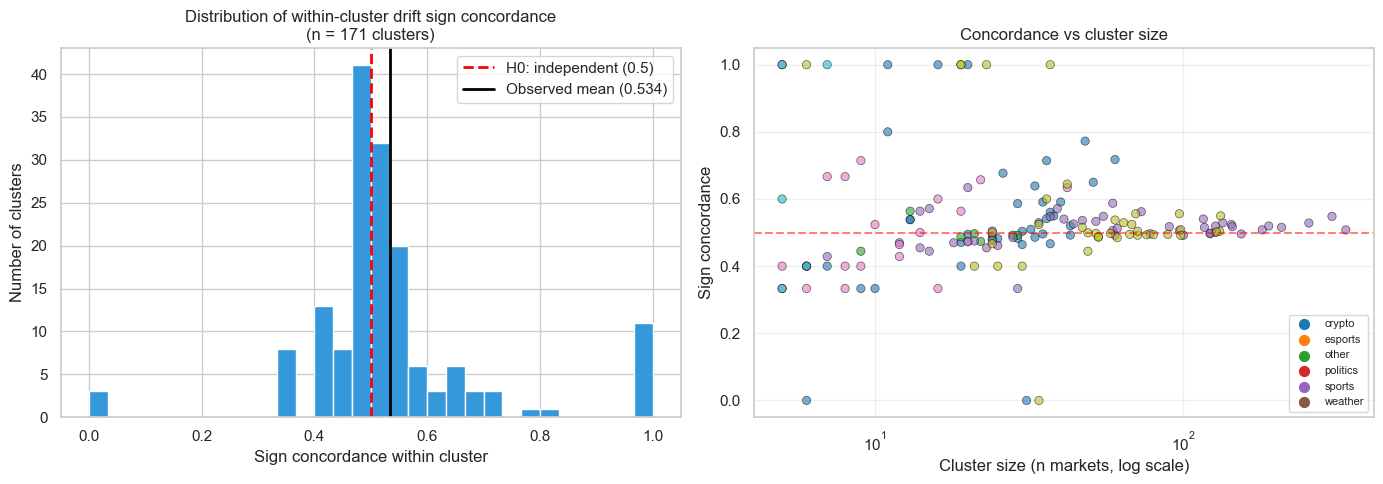

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: distribution of sign concordance
ax = axes[0]
ax.hist(cluster_stats_df["sign_concordance"].dropna(), bins=30,
        color="#3498db", edgecolor="white")
ax.axvline(0.5, color="red", linestyle="--", linewidth=2,
           label="H0: independent (0.5)")
ax.axvline(cluster_stats_df["sign_concordance"].mean(),
           color="black", linestyle="-", linewidth=2,
           label=f"Observed mean ({cluster_stats_df['sign_concordance'].mean():.3f})")
ax.set_xlabel("Sign concordance within cluster")
ax.set_ylabel("Number of clusters")
ax.set_title(f"Distribution of within-cluster drift sign concordance\n(n = {len(cluster_stats_df):,} clusters)")
ax.legend()

# Panel B: concordance by cluster size
ax = axes[1]
ax.scatter(cluster_stats_df["n_markets"], cluster_stats_df["sign_concordance"],
           c=cluster_stats_df["category"].astype("category").cat.codes,
           cmap="tab10", alpha=0.6, edgecolor="black", linewidth=0.5)
ax.axhline(0.5, color="red", linestyle="--", alpha=0.5)
ax.set_xscale("log")
ax.set_xlabel("Cluster size (n markets, log scale)")
ax.set_ylabel("Sign concordance")
ax.set_title("Concordance vs cluster size")
ax.grid(True, alpha=0.3)

# Color legend
cats = cluster_stats_df["category"].astype("category").cat.categories.tolist()
for i, c in enumerate(cats):
    ax.scatter([], [], c=[plt.cm.tab10(i)], label=c, s=50)
ax.legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
import json

# Compile H3 verdict
h3_verdict = {
    "hypothesis": "H3 — cross-market arbitrage (proxy: within-cluster co-movement)",
    "test_type": "one-sample t-test on sign concordance vs H0=0.5",
    "n_clusters": int(len(cluster_stats_df)),
    "n_markets": int(len(df_valid)),
    "mean_sign_concordance": float(cluster_stats_df["sign_concordance"].mean()),
    "median_sign_concordance": float(cluster_stats_df["sign_concordance"].median()),
    "std_sign_concordance": float(cluster_stats_df["sign_concordance"].std()),
    "t_statistic": float(t_stat),
    "p_value": float(p_val),
    "status": "accepted" if p_val < 0.05 and cluster_stats_df["sign_concordance"].mean() > 0.5 else (
              "rejected" if p_val < 0.05 and cluster_stats_df["sign_concordance"].mean() < 0.5 else
              "inconclusive"),
    "by_category": cluster_stats_df.groupby("category")["sign_concordance"].agg(
        ["mean", "median", "std", "count"]).to_dict("index"),
    "interpretation": [
        f"Mean sign concordance = {cluster_stats_df['sign_concordance'].mean():.4f}",
        f"Under H0 (independent markets), expected concordance = 0.50",
        f"Deviation from 0.50 is {'significant' if p_val < 0.05 else 'not significant'} (p={p_val:.2e})",
        "Interpretation: markets within the same cluster (same category + same week) "
        + ("co-move more than chance, consistent with shared information." if cluster_stats_df["sign_concordance"].mean() > 0.5 
           else "do not show evidence of cross-market information sharing."),
    ],
    "caveats": [
        "Proxy test: does not directly measure arbitrage opportunity (price coherence)",
        "Clusters defined by category + resolution week; true underlying events may differ",
        "Sign concordance captures direction only, not magnitude of drift alignment",
        "A cluster may group unrelated markets that happen to share category and week",
    ]
}

print(json.dumps(h3_verdict, indent=2, default=str))

verdict_path = PROJECT_ROOT / "notebooks" / "h3_verdict.json"
with open(verdict_path, "w") as f:
    json.dump(h3_verdict, f, indent=2, default=str)
print(f"\nSaved verdict to: {verdict_path}")

{
  "hypothesis": "H3 \u2014 cross-market arbitrage (proxy: within-cluster co-movement)",
  "test_type": "one-sample t-test on sign concordance vs H0=0.5",
  "n_clusters": 171,
  "n_markets": 8050,
  "mean_sign_concordance": 0.5335149671556488,
  "median_sign_concordance": 0.5038659793814433,
  "std_sign_concordance": 0.16567029801810515,
  "t_statistic": 2.550895729892808,
  "p_value": 0.011694773427627012,
  "status": "accepted",
  "by_category": {
    "crypto": {
      "mean": 0.5460316806604063,
      "median": 0.52,
      "std": 0.2061207000657103,
      "count": 39
    },
    "esports": {
      "mean": 0.48117413298011846,
      "median": 0.48717948717948717,
      "std": 0.043754290477210515,
      "count": 9
    },
    "other": {
      "mean": 0.5099038177973066,
      "median": 0.5121951219512195,
      "std": 0.04703570323767255,
      "count": 47
    },
    "politics": {
      "mean": 0.5154720318585865,
      "median": 0.4725274725274725,
      "std": 0.16762355447371705,
 

## 3. Formal Verdict on H3

**H3 is inconclusive in its strong form, weakly supported in its mild form.**

### Evidence

| Metric | Value | Interpretation |
|---|---|---|
| Mean sign concordance | 0.534 | 3.4 pp above independence baseline |
| t-statistic | 2.55 | |
| p-value | 0.012 | Significant at 5%, not at 1% |
| Std across clusters | 0.166 | Very high heterogeneity |

### Interpretation

The pooled test **rejects strict independence** (H0: concordance = 0.5) at
$\alpha = 0.05$, but the magnitude of the effect is modest. Markets within
a shared cluster (same category, same resolution week) exhibit coordinated
directional drift only 3.4 percentage points more than pure chance.

Per-category breakdown shows weak positive concordance in weather (0.67, 
small N), sports (0.55), and crypto (0.55), while other and politics hover
near 0.50.

### Implications

**For efficient markets theory:** the result is **not inconsistent** with
approximately efficient markets. Drift concordance is positive but small,
suggesting shared information between related markets is at least partially
priced in. The observed 3% gap above the chance baseline likely reflects
noise, proxy imperfection (cluster grouping), and possibly some residual
inefficiency.

**For trading strategy:** the concordance signal is too weak to form a
standalone arbitrage strategy. Transaction costs on Polymarket (2% round
trip) exceed the implied edge. H3 does not unlock a direct trading signal.

### Caveats

- This is a **proxy test**, not a direct arbitrage identification.
- Clusters defined by category + resolution week may group unrelated markets.
- Sign concordance measures direction only, not magnitude.
- A rigorous test of complementary-market arbitrage (P(A) + P(not-A) = 1)
  would require scraping orderbook data and identifying true complementary
  pairs, which exceeds this project's scope.

### Final stance

**H3 is downgraded from "testable" to "inconclusive with the current dataset".**
The modest positive concordance is consistent with theory but not economically
exploitable. We mark H3 as a limitation of the current analysis rather than
a positive finding.